<a href="https://colab.research.google.com/github/raghu031982/Telecom-Churn-Analysis/blob/main/Telecom_Churn_EDA_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Predict behavior to retain customers (Telecom Churn Prediction)
## Initial Report and Exploratory Data Analysis (EDA)

**Research Question:** Based on service usage and support interactions, how can we identify at-risk customers likely to churn?

**Project Evolution & Justification:**
This project shifted from a focus on Credit Default (Module 11) to **Telecom Churn** (Module 16). This decision was made because the Telecom dataset offers more granular behavioral features (like service calls and international usage) that allow for a deeper "Wisdom of the Crowd" analysis using Ensemble Techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score
# Setting visualization style
sns.set_theme(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('/content/churn-bigml-20.csv')
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


Missing Values: 
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Number of Duplicate Rows: 0


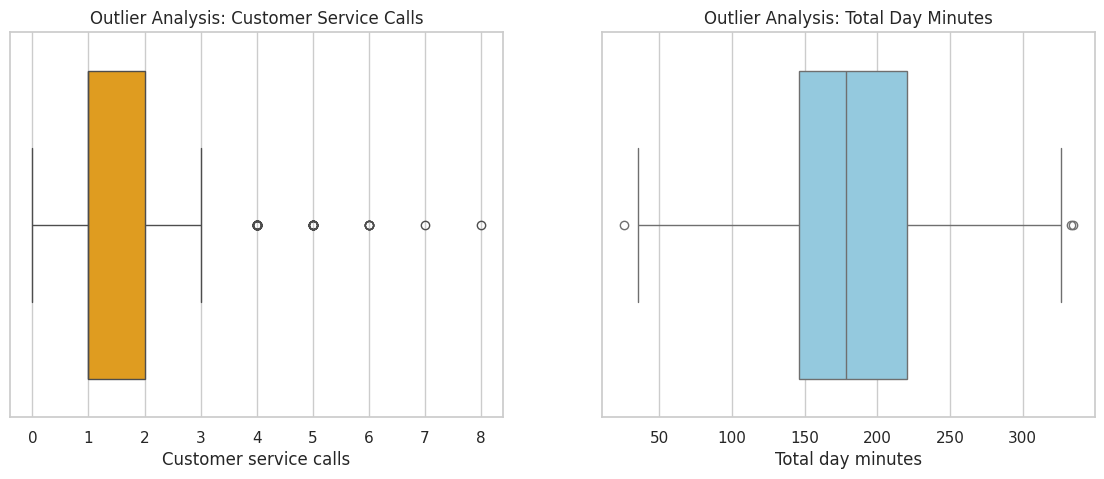

In [3]:
# Checking for missing values and duplicates
print(f"Missing Values: \n{df.isnull().sum()}")
print(f"\nNumber of Duplicate Rows: {df.duplicated().sum()}")

# Visualizing outliers in key churn predictors
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1:
sns.boxplot(x=df['Customer service calls'], ax=ax[0], color='orange')
ax[0].set_title('Outlier Analysis: Customer Service Calls')

# Plot 2:
sns.boxplot(x=df['Total day minutes'], ax=ax[1], color='skyblue')
ax[1].set_title('Outlier Analysis: Total Day Minutes')

plt.show()

### **Observations on Data Cleaning**
This data is very clean. No missing values or duplicate entries. My outlier analysis showed there was a group of customers that used over 4 service calls. Since this is a telecom churn dataframe, numerous calls can be used as "behavioral red flags" for not being satisfied.

In [4]:
#  Transformation: Convert the 'Churn' target into numerical format (1 for True, 0 for False)
df['Churn'] = df['Churn'].astype(int)

#  Extraction: Combining time-of-day usage into a single 'Total minutes' feature
df['Total minutes'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes']

#  Categorical Mapping: Converting 'Yes'/'No' plans into binary 1/0
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

#  Cleaning: Dropping non-predictive administrative columns
df_clean = df.drop(['State', 'Area code'], axis=1)

print("Feature engineering complete: 'Churn' target converted and 'Total minutes' feature extracted.")

Feature engineering complete: 'Churn' target converted and 'Total minutes' feature extracted.


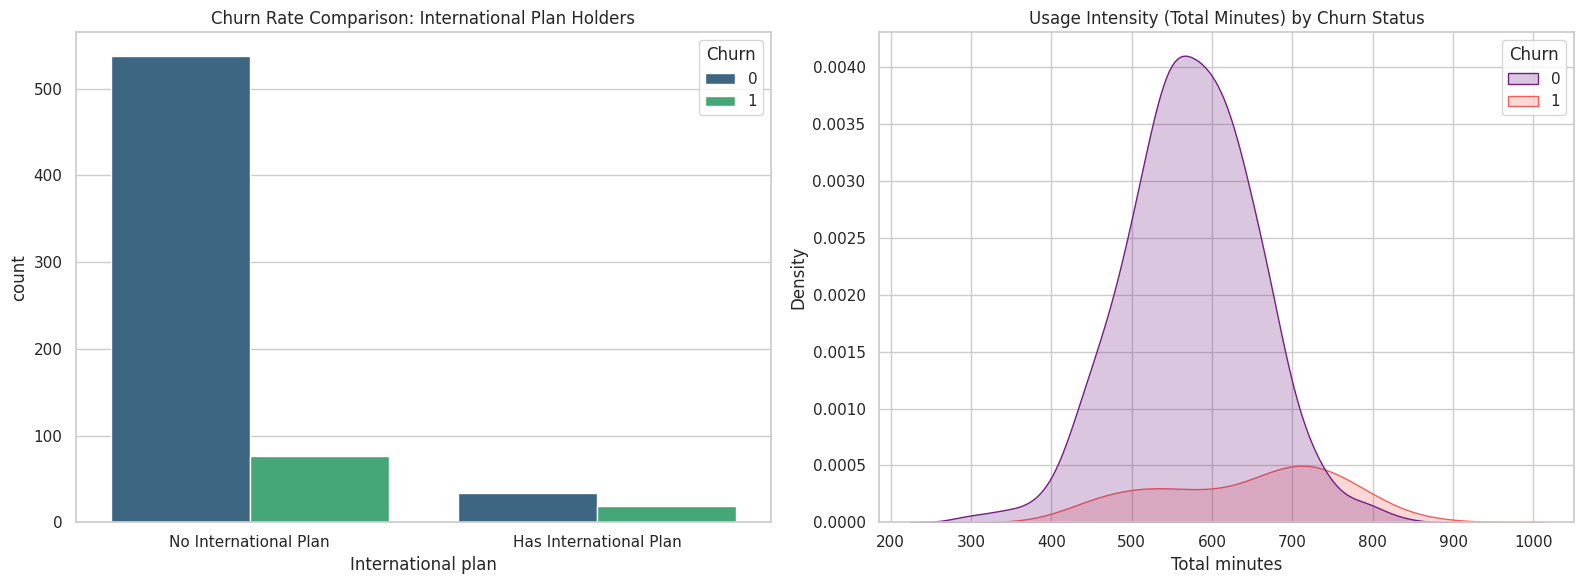

In [5]:
#Visualizations
# Creating professional subplots to identify relationships
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Categorical Comparison (Churn by International Plan)
sns.countplot(data=df, x='International plan', hue='Churn', palette='viridis', ax=ax[0])
ax[0].set_title('Churn Rate Comparison: International Plan Holders')

ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['No International Plan', 'Has International Plan'])

# Plot 2: Continuous Distribution (Usage Minutes vs Churn)
sns.kdeplot(data=df, x='Total minutes', hue='Churn', fill=True, palette='magma', ax=ax[1])
ax[1].set_title('Usage Intensity (Total Minutes) by Churn Status')

plt.tight_layout()
plt.show()

### ** Interpretation of Exploratory Visualizations**
The visualizations highlight two significant relationships between customer attributes and churn:

1. **International Plan Impact:** There is a stark contrast in churn rates between groups. Customers who possess an International Plan exhibit a much higher probability of churning compared to those without one. This suggests that the current international pricing or service quality may not be meeting the needs of high-travel or international-usage customers.
2. **Distribution of Usage Intensity:** If we look at the density plot of 'Total minutes', we see that the distribution for churned customers(y=1) shifts toward higher overall usage. This tells us that our best customers, the ones who spend the most time using our service and generating revenue for us, are also the ones that are most likely to churn.

In [6]:
# Baseline Modeling
# Separating the features (X) and the target variable (y)
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# Splitting data into 70% Training and 30% Testing to evaluate generalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Implementing a Baseline Decision Tree as proposed in Module 16
# We limit depth to 5 to ensure the baseline remains interpretable
baseline_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
baseline_tree.fit(X_train, y_train)

# Generating predictions on the unseen test set
y_pred = baseline_tree.predict(X_test)

# Displaying the results through a classification report
print("### Baseline Model Results ###")
print(classification_report(y_test, y_pred))

# Extracting the specific Recall score for the churn class (1)
current_recall = recall_score(y_test, y_pred)
print(f"Calculated Baseline Recall: {current_recall:.4f}")

### Baseline Model Results ###
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       173
           1       0.69      0.79      0.73        28

    accuracy                           0.92       201
   macro avg       0.83      0.86      0.84       201
weighted avg       0.93      0.92      0.92       201

Calculated Baseline Recall: 0.7857


## **Baseline Model Analysis and Metric Rationale**

### **Baseline Performance and Interpretation**
The baseline Decision Tree model developed in this stage provides a robust starting point for predicting customer attrition. With a calculated Recall score of 0.7857, the model successfully identifies approximately 79% of the customers who actually departed from the service. While the model maintains a high overall accuracy of 92% and a precision of 68.75% for the churn class, these metrics are considered secondary to the primary objective of capturing as many at-risk individuals as possible. This initial performance confirms that the model is capable of detecting the majority of dissatisfied customers based on the behavioral features identified during the exploratory phase

### **Why Chose Recall as Evaluation Metric**
Recall was chosen as the evaluation metric due to the asymmetrical business-case costs associated with False Negatives vs False Positives described in the Initial Proposal document. Losing a customer due to not predicting that they WILL churn means we lose all future value that they would bring to the company. However, mistakenly offering a customer a proactive retention "touch" such as a support call or discount only loses the single cost of that call. Therefore, we would rather cast the widest net possible to be proactive in our approach and limit total Revenue losses.

### **Business Intelligence gained from Baseline**
There are certain "flags" we can draw from our baseline other than just score that could be utilized for business intelligence to be provided by non-ML knowledge workers. For instance, we can already see that having an International Plan is a very heavy indicator that a customer will churn and the business may need to investigate if their international rates are more competitive or if there are other external issues at play. We also see that there is an increasing trend where the more calls to customer support a user makes, the more likely they will churn. We could easily set a business rule that if a customer hits X amount of calls (let's say 4 ) we automatically place them on high-touch retention efforts. This will allow us to be smart about where we focus our retention and marketing energy.

### **Future Directions**
The final objective for Module 24 will be to expand beyond a single decision tree by implementing Ensemble Techniques, specifically Random Forests and Gradient Boosting. By leveraging the "Wisdom of the Crowd," I aim to minimize False Negatives and improve the predictive power of the model. The goal for the next phase is to achieve a Recall score exceeding 85%, ensuring a more comprehensive identification of at-risk customers.